# Modelo unificado SESCO — 6 recursos MVP

Procesa en lote los recursos de producción promedio diaria (petróleo y gas por provincia, cuenca y empresa) y genera un dataset unificado para el dashboard.

## 1. Configuración e imports

In [90]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

NOTEBOOK_DIR = Path.cwd()
EXPLORATION_DIR = (
    NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "exploration"
)
SCRIPTS_DIR = EXPLORATION_DIR / "scripts"
RAW_DIR = EXPLORATION_DIR / "data" / "raw"
PROCESSED_DIR = EXPLORATION_DIR / "data" / "processed"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import sesco_processing as sp
sp = importlib.reload(sp)


RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Exploration: {EXPLORATION_DIR}")


Exploration: c:\Proyectos\Dashboards\OilAndGas\exploration


## 2. Recursos MVP

In [91]:
SESCO_RESOURCES = {
    "petroleo_provincia": {
        "producto": "petroleo",
        "agrupador_tipo": "provincia",
        "nombre_recurso": "Producción de petróleo promedio diaria por provincia",
    },
    "gas_provincia": {
        "producto": "gas",
        "agrupador_tipo": "provincia",
        "nombre_recurso": "Producción de gas promedio diaria por provincia",
    },
    "petroleo_cuenca": {
        "producto": "petroleo",
        "agrupador_tipo": "cuenca",
        "nombre_recurso": "Producción de petróleo promedio diaria por cuenca",
    },
    "gas_cuenca": {
        "producto": "gas",
        "agrupador_tipo": "cuenca",
        "nombre_recurso": "Producción de gas promedio diaria por cuenca",
    },
    "petroleo_empresa": {
        "producto": "petroleo",
        "agrupador_tipo": "empresa",
        "nombre_recurso": "Producción de petróleo promedio diaria por empresa",
    },
    "gas_empresa": {
        "producto": "gas",
        "agrupador_tipo": "empresa",
        "nombre_recurso": "Producción de gas promedio diaria por empresa",
    },
}

list(SESCO_RESOURCES.keys())


['petroleo_provincia',
 'gas_provincia',
 'petroleo_cuenca',
 'gas_cuenca',
 'petroleo_empresa',
 'gas_empresa']

## 3. Consultar CKAN y listar recursos

In [92]:
package = sp.fetch_ckan_package()
df_resources = sp.list_resources(package)
print(f"Dataset: {package.get('title')}")
print(f"Recursos CKAN: {len(df_resources)}")
df_resources[["name", "format", "last_modified"]].head(10)


Dataset: Producción de Petróleo y Gas (SESCO)
Recursos CKAN: 41


,name,format,last_modified
0,Producción de Petróleo y Gas - desde 2019 - Se...,ZIP,2023-11-24T17:11:31.273629
1,Balances de Gas - desde 2009 - Sesco Web (Tabl...,ZIP,2019-03-07T15:19:37.091230
2,Producción de Petróleo y Gas - 2009 a 2018 - (...,ZIP,2023-11-24T17:03:36.936971
3,Producción de Petróleo y Gas - hasta 2008 - (...,ZIP,NaN
4,Disponibilidad de petróleo a fin de mes ant. 2009,CSV,2017-07-28T09:44:37.454531
5,Dist. de condensado y existencias a fin de mes...,CSV,2017-07-28T09:44:52.176571
6,Distribucion de gasolina y existencias a fin d...,CSV,2017-07-28T09:45:10.519549
7,Distribución de petróleo y existencias a fin d...,CSV,2017-07-28T09:45:34.620611
8,Producción de GLP Condensado y Gasolina Estabi...,CSV,2023-01-17T09:51:16.612783
9,Producción de petróleo anterior al 2009,CSV,2017-07-28T09:56:56.559201


## 4. Procesar los 6 recursos

In [93]:
results, df_sesco_model, df_validaciones = sp.process_all_resources(
    SESCO_RESOURCES,
    verbose=False,
)

1
2
3
4
5
6
[     periodo_str  periodo_dt  anio  mes  producto agrupador_tipo  \
0        2009-01  2009-01-01  2009    1  petroleo      provincia   
1        2009-01  2009-01-01  2009    1  petroleo      provincia   
2        2009-01  2009-01-01  2009    1  petroleo      provincia   
3        2009-01  2009-01-01  2009    1  petroleo      provincia   
4        2009-01  2009-01-01  2009    1  petroleo      provincia   
...          ...         ...   ...  ...       ...            ...   
2493     2025-12  2025-12-01  2025   12  petroleo      provincia   
2494     2025-12  2025-12-01  2025   12  petroleo      provincia   
2495     2025-12  2025-12-01  2025   12  petroleo      provincia   
2496     2025-12  2025-12-01  2025   12  petroleo      provincia   
2497     2025-12  2025-12-01  2025   12  petroleo      provincia   

      agrupador_nombre     tipo_recurso    produccion  \
0               Chubut  promedio_diario  25615.042484   
1      Estado Nacional  promedio_diario    684.083226   

In [94]:
df_sesco_model

,periodo_str,periodo_dt,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource
0,2009-01,2009-01-01,2009,1,petroleo,provincia,Chubut,promedio_diario,25615.042484,Producción de petróleo promedio diaria por pro...
1,2009-01,2009-01-01,2009,1,petroleo,provincia,Estado Nacional,promedio_diario,684.083226,Producción de petróleo promedio diaria por pro...
2,2009-01,2009-01-01,2009,1,petroleo,provincia,Formosa,promedio_diario,416.606452,Producción de petróleo promedio diaria por pro...
3,2009-01,2009-01-01,2009,1,petroleo,provincia,Jujuy,promedio_diario,46.487742,Producción de petróleo promedio diaria por pro...
4,2009-01,2009-01-01,2009,1,petroleo,provincia,La Pampa,promedio_diario,3925.047097,Producción de petróleo promedio diaria por pro...
...,...,...,...,...,...,...,...,...,...,...
33907,2026-04,2026-04-01,2026,4,gas,empresa,TOTAL AUSTRAL S.A.,promedio_diario,32728.881700,Producción de gas promedio diaria por empresa
33908,2026-04,2026-04-01,2026,4,gas,empresa,VACA MUERTA INVERSIONES SAU,promedio_diario,297.265333,Producción de gas promedio diaria por empresa
33909,2026-04,2026-04-01,2026,4,gas,empresa,VENOIL S.A.,promedio_diario,165.942667,Producción de gas promedio diaria por empresa
33910,2026-04,2026-04-01,2026,4,gas,empresa,VISTA ENERGY ARGENTINA SAU,promedio_diario,1399.710667,Producción de gas promedio diaria por empresa


In [95]:
df_validaciones

,resource_key,producto,agrupador_tipo,cantidad_filas_original,cantidad_filas_limpias,periodo_min,periodo_max_disponible,latest_valid_period,excluded_period,cantidad_agrupadores,cantidad_nulos_produccion,cantidad_produccion_negativa,observaciones
0,petroleo_provincia,petroleo,provincia,2505,2498,2009-01,2026-01,2025-12,2026-01,15,0,0,excluido periodo 2026-01
1,gas_provincia,gas,provincia,2493,2488,2009-01,2026-04,2026-03,2026-04,15,0,0,excluido periodo 2026-04
2,petroleo_cuenca,petroleo,cuenca,2013,2013,2009-01,2025-11,2025-11,,17,0,0,
3,gas_cuenca,gas,cuenca,2062,2059,2009-01,2026-05,2026-04,2026-05,17,0,0,excluido periodo 2026-05
4,petroleo_empresa,petroleo,empresa,12508,12507,2009-01,2026-05,2026-04,2026-05,127,0,1,excluido periodo 2026-05
5,gas_empresa,gas,empresa,12348,12347,2009-01,2026-05,2026-04,2026-05,127,0,0,excluido periodo 2026-05


## 5. Exportar dataset unificado y validaciones

In [96]:
# Asegurar periodo_dt como datetime para análisis en notebook
if len(df_sesco_model) and not pd.api.types.is_datetime64_any_dtype(
    df_sesco_model["periodo_dt"]
):
    df_sesco_model["periodo_dt"] = pd.to_datetime(df_sesco_model["periodo_dt"])

unified_path, valid_path = sp.export_unified(
    df_sesco_model, df_validaciones, PROCESSED_DIR
)
print(f"Unificado: {unified_path} ({len(df_sesco_model):,} filas)")
print(f"Validaciones: {valid_path}")


Unificado: c:\Proyectos\Dashboards\OilAndGas\exploration\data\processed\sesco_produccion_model_clean.csv (33,912 filas)
Validaciones: c:\Proyectos\Dashboards\OilAndGas\exploration\data\processed\sesco_validaciones_resumen.csv


## 6. Validaciones del dataset unificado

In [97]:
unified_checks = sp.validate_unified_dataset(df_sesco_model)

print(f"Total filas: {unified_checks['total_filas']:,}")
print(f"Productos: {unified_checks['productos']}")
print(f"Agrupador tipos: {unified_checks['agrupador_tipos']}")
print(f"Período: {unified_checks['periodo_min']} → {unified_checks['periodo_max']}")
print()
print("Registros por producto y agrupador_tipo:")
display(pd.Series(unified_checks["registros_por_producto_tipo"]).sort_index())
print()
print("Agrupadores únicos por producto y agrupador_tipo:")
display(pd.Series(unified_checks["agrupadores_unicos_por_producto_tipo"]).sort_index())
print()
print(f"Duplicados (clave {sp.DUPLICATE_KEY_COLUMNS}): {unified_checks['duplicados_cantidad']}")
if unified_checks["duplicados_cantidad"] > 0:
    display(unified_checks["duplicados_muestra"])

# Validación comparativa entre vistas de agregación (NO suma entre vistas)
df_totales_comparados = sp.build_totals_comparison_table(df_sesco_model)

display(df_totales_comparados.head(20))
print("Comparación reciente (últimos 12 períodos por producto):")
display(df_totales_comparados.groupby("producto").tail(12))


Total filas: 33,912
Productos: ['gas', 'petroleo']
Agrupador tipos: ['cuenca', 'empresa', 'provincia']
Período: 2009-01 → 2026-04

Registros por producto y agrupador_tipo:


gas       cuenca        2059
          empresa      12347
          provincia     2488
petroleo  cuenca        2013
          empresa      12507
          provincia     2498
dtype: int64


Agrupadores únicos por producto y agrupador_tipo:


gas       cuenca        17
          empresa      127
          provincia     15
petroleo  cuenca        17
          empresa      127
          provincia     15
dtype: int64


Duplicados (clave ['periodo_str', 'producto', 'agrupador_tipo', 'agrupador_nombre', 'tipo_recurso']): 0


,periodo_str,producto,total_cuenca,total_empresa,total_provincia,diff_cuenca_vs_provincia_pct,diff_empresa_vs_provincia_pct
0,2009-01,gas,131223.010820,131223.010820,131223.010820,2.217891e-14,4.435782e-14
1,2009-02,gas,132833.268311,132833.268311,132833.268311,2.191005e-14,0.000000e+00
2,2009-03,gas,135361.204784,135361.204784,135361.204784,-6.450260e-14,-8.600346e-14
3,2009-04,gas,135493.246151,135493.246151,135493.246151,0.000000e+00,8.591965e-14
4,2009-05,gas,135374.432953,135374.432953,135374.432953,-4.299753e-14,-2.149876e-14
5,2009-06,gas,138925.003551,138925.003551,138925.003551,-2.094931e-14,-4.189862e-14
6,2009-07,gas,138202.710745,138202.710745,138202.710745,2.105880e-14,4.211760e-14
7,2009-08,gas,129584.371960,129584.371960,129584.371960,1.122968e-13,0.000000e+00
8,2009-09,gas,133147.567907,133147.567907,133147.567907,8.743331e-14,4.371665e-14
9,2009-10,gas,132800.720557,132800.720557,132800.720557,-2.191542e-14,0.000000e+00


Comparación reciente (últimos 12 períodos por producto):


,periodo_str,producto,total_cuenca,total_empresa,total_provincia,diff_cuenca_vs_provincia_pct,diff_empresa_vs_provincia_pct
196,2025-05,gas,147680.441435,147680.441435,147680.441435,-7.882921e-14,-3.941460e-14
197,2025-06,gas,159351.142927,159351.142927,159351.142927,4.565990e-13,1.278477e-13
198,2025-07,gas,160761.595592,160761.595592,160761.595592,-3.620744e-13,-9.051860e-14
199,2025-08,gas,158098.854535,158098.854535,158098.854535,3.681726e-13,2.577208e-13
200,2025-09,gas,138645.908333,138645.908333,138647.448000,-1.110490e-03,-1.110490e-03
201,2025-10,gas,123975.301897,123975.301897,123975.301897,4.695101e-14,3.521326e-14
202,2025-11,gas,122217.010333,122217.010333,122217.577333,-4.639267e-04,-4.639267e-04
203,2025-12,gas,131745.323023,131745.323023,131679.223023,5.019774e-02,5.019774e-02
204,2026-01,gas,131675.455410,131675.455410,131617.468313,4.405730e-02,4.405730e-02
205,2026-02,gas,140090.148250,140090.148250,140028.135750,4.428574e-02,4.428574e-02


## 7. Gráficos exploratorios — dataset unificado

**Advertencia metodológica:** `provincia`, `cuenca` y `empresa` son distintas vistas de agregación del mismo fenómeno. No deben sumarse entre sí para estimar totales nacionales. Para totales mensuales nacionales se usa `agrupador_tipo = "provincia"` como fuente base.

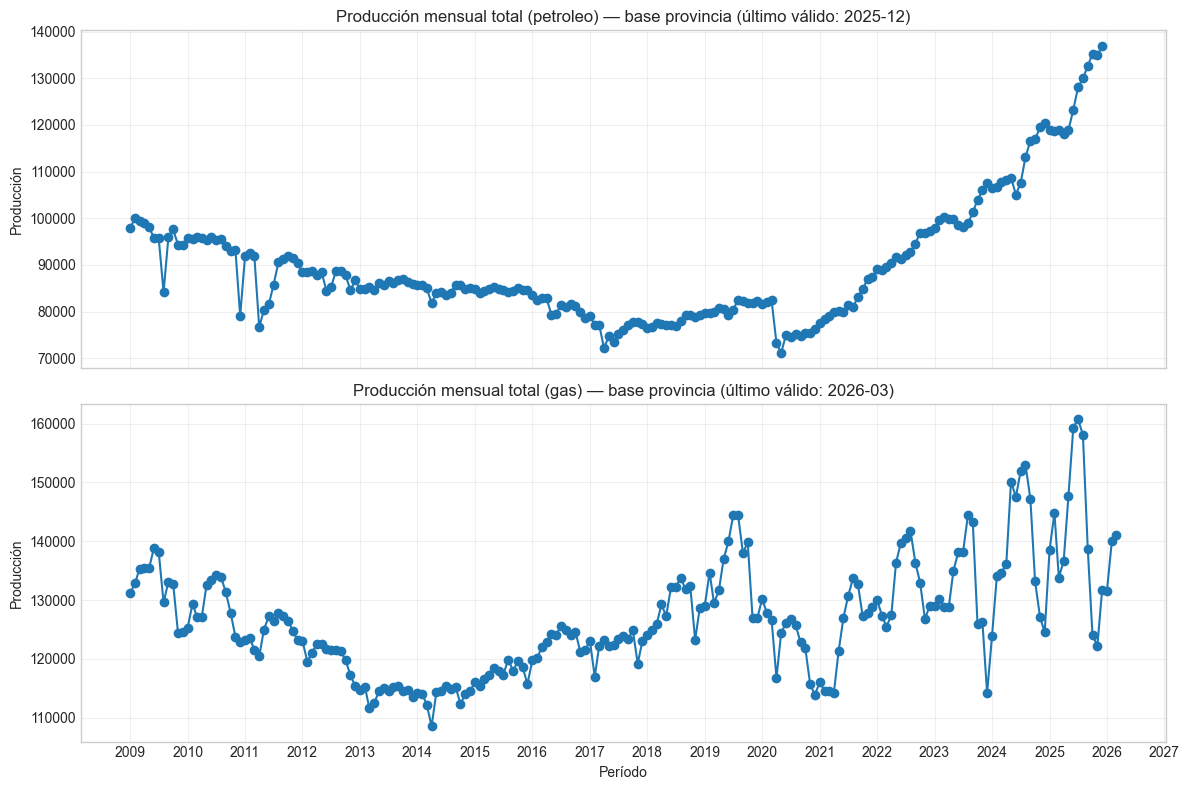

In [55]:
# Helpers de períodos válidos por producto + agrupador_tipo

def get_valid_periods_by_group(df, producto, agrupador_tipo, threshold=0.5):
    info = sp.get_valid_periods_by_group(
        df,
        producto=producto,
        agrupador_tipo=agrupador_tipo,
        threshold=threshold,
        verbose=True,
    )
    return info


def filter_valid_group(df, producto, agrupador_tipo, threshold=0.5):
    info = get_valid_periods_by_group(df, producto, agrupador_tipo, threshold)
    sub = df[
        (df["producto"] == producto)
        & (df["agrupador_tipo"] == agrupador_tipo)
        & (df["periodo_dt"].isin(info["periodos_validos"]))
    ].copy()
    return sub, info


# Gráfica 1: producción total mensual por producto (base provincia)
# Importante: NO sumar provincia+cuenca+empresa.
df_base_total = df_sesco_model[df_sesco_model["agrupador_tipo"] == "provincia"].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for idx, producto in enumerate(["petroleo", "gas"]):
    sub, info = filter_valid_group(df_base_total, producto, "provincia", threshold=0.5)
    ts_producto = (
        sub.groupby(["periodo_dt", "periodo_str"], as_index=False)["produccion"]
        .sum()
        .sort_values("periodo_dt")
    )
    axes[idx].plot(ts_producto["periodo_dt"], ts_producto["produccion"], marker="o")
    axes[idx].set_title(
        f"Producción mensual total ({producto}) — base provincia "
        f"(último válido: {info['latest_valid_period']})"
    )
    axes[idx].set_ylabel("Producción")
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("Período")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()



--- petróleo / provincia ---


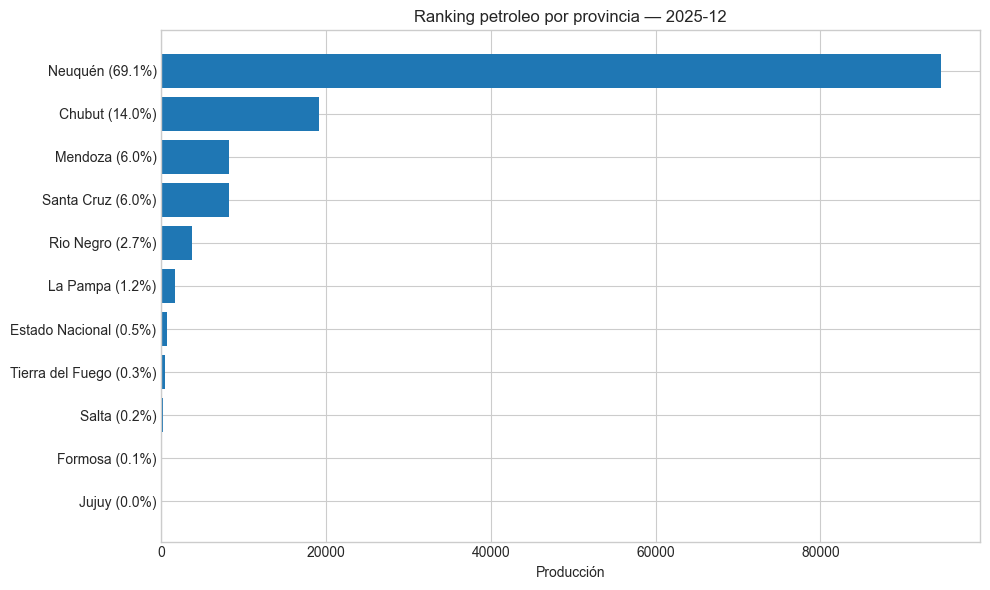


--- petróleo / cuenca ---


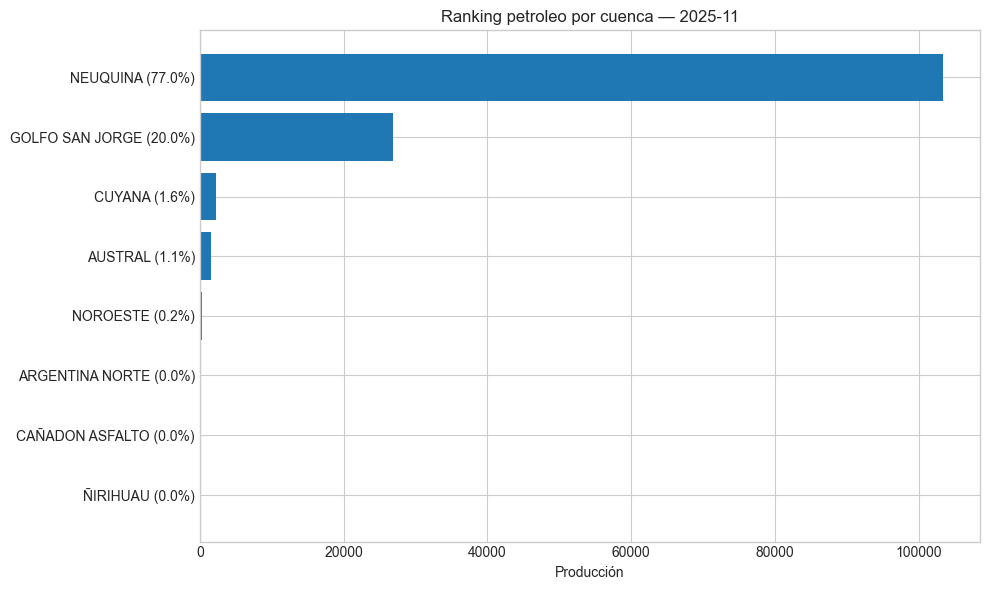


--- petróleo / empresa ---


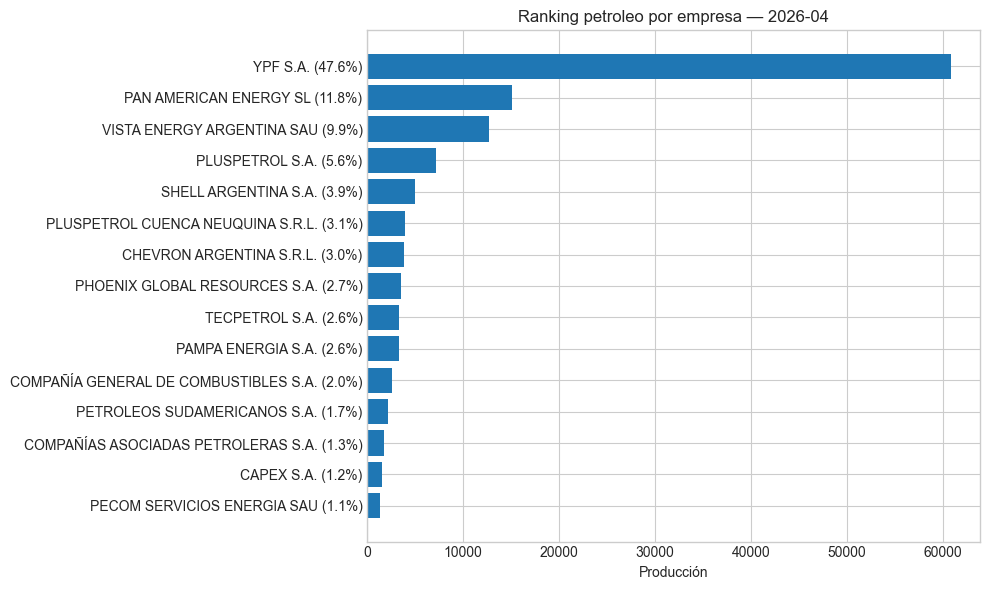


--- gas / provincia ---


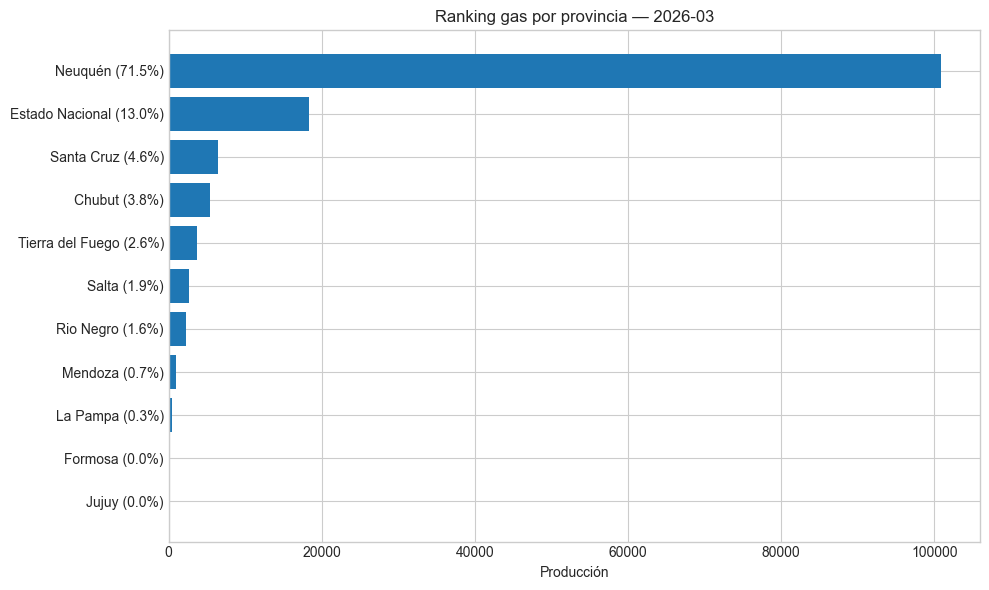


--- gas / cuenca ---


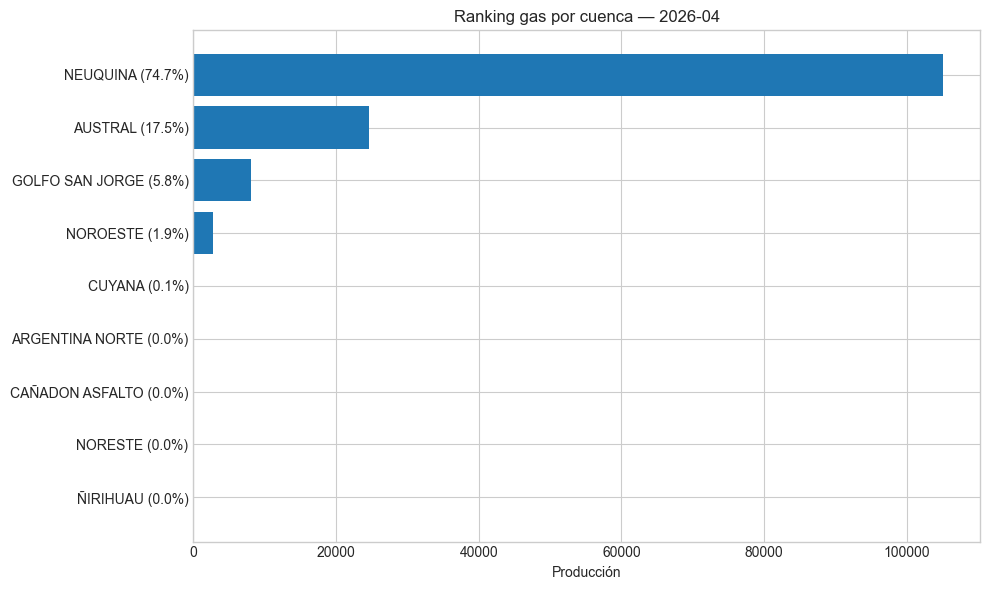


--- gas / empresa ---


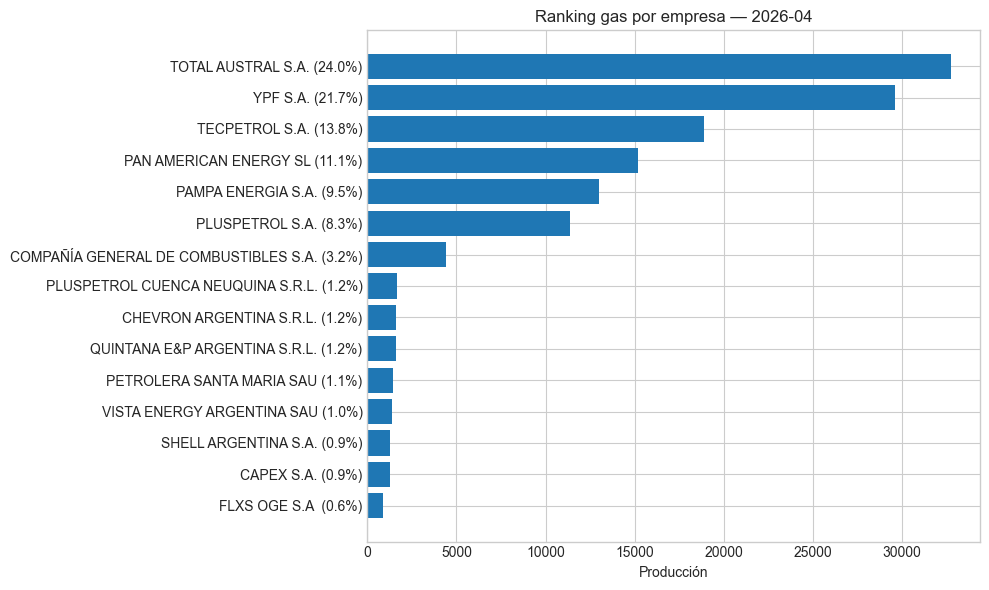

In [56]:
def plot_ranking_ultimo_periodo(df, producto, agrupador_tipo, top_n=15):
    """Ranking en el último período válido por producto + agrupador_tipo."""
    sub, info = filter_valid_group(df, producto, agrupador_tipo, threshold=0.5)
    if sub.empty:
        print(f"Sin datos para {producto}/{agrupador_tipo}")
        return None

    ultimo = info["latest_valid_period"]
    df_p = sub[sub["periodo_str"] == ultimo]
    ranking = (
        df_p.groupby("agrupador_nombre", as_index=False)["produccion"]
        .sum()
        .sort_values("produccion", ascending=False)
        .head(top_n)
    )
    total = ranking["produccion"].sum()
    ranking["pct"] = ranking["produccion"] / total * 100
    ranking["label"] = ranking.apply(
        lambda r: f"{r['agrupador_nombre']} ({r['pct']:.1f}%)", axis=1
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(ranking["label"], ranking["produccion"])
    ax.invert_yaxis()
    ax.set_title(f"Ranking {producto} por {agrupador_tipo} — {ultimo}")
    ax.set_xlabel("Producción")
    plt.tight_layout()
    plt.show()
    return ranking


for tipo in ("provincia", "cuenca", "empresa"):
    print(f"\n--- petróleo / {tipo} ---")
    plot_ranking_ultimo_periodo(df_sesco_model, "petroleo", tipo)

for tipo in ("provincia", "cuenca", "empresa"):
    print(f"\n--- gas / {tipo} ---")
    plot_ranking_ultimo_periodo(df_sesco_model, "gas", tipo)


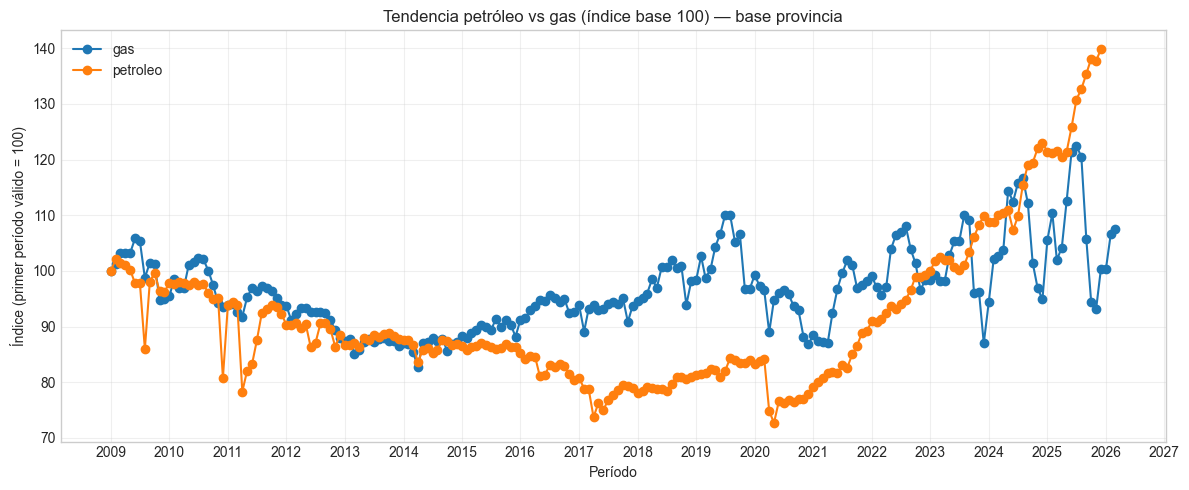

,periodo_dt,periodo_str,produccion,indice_base_100,producto
399,2025-04-01,2025-04,136720.866577,104.189704,gas
400,2025-05-01,2025-05,147680.441435,112.541574,gas
401,2025-06-01,2025-06,159351.142927,121.435366,gas
402,2025-07-01,2025-07,160761.595592,122.510217,gas
403,2025-08-01,2025-08,158098.854535,120.481045,gas
404,2025-09-01,2025-09,138647.448000,105.657877,gas
405,2025-10-01,2025-10,123975.301897,94.476800,gas
406,2025-11-01,2025-11,122217.577333,93.137306,gas
407,2025-12-01,2025-12,131679.223023,100.347662,gas
408,2026-01-01,2026-01,131617.468313,100.300601,gas


In [57]:
# Comparación de tendencia petróleo vs gas (índice base 100, base provincia)
rows = []
for producto in ["petroleo", "gas"]:
    sub, info = filter_valid_group(df_sesco_model, producto, "provincia", threshold=0.5)
    ts = (
        sub.groupby(["periodo_dt", "periodo_str"], as_index=False)["produccion"]
        .sum()
        .sort_values("periodo_dt")
    )
    base = ts.iloc[0]["produccion"] if len(ts) else None
    if base and base != 0:
        ts["indice_base_100"] = ts["produccion"] / base * 100
        ts["producto"] = producto
        rows.append(ts)

compare_idx = pd.concat(rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 5))
for producto, grp in compare_idx.groupby("producto"):
    ax.plot(grp["periodo_dt"], grp["indice_base_100"], marker="o", label=producto)
ax.set_title("Tendencia petróleo vs gas (índice base 100) — base provincia")
ax.set_xlabel("Período")
ax.set_ylabel("Índice (primer período válido = 100)")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(compare_idx.tail(12))


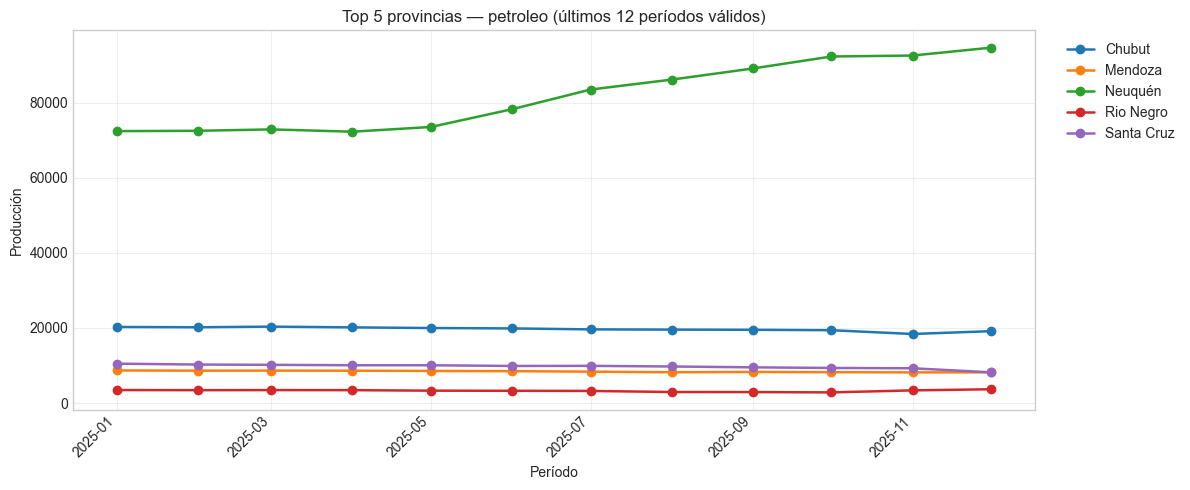

agrupador_nombre,Chubut,Mendoza,Neuquén,Rio Negro,Santa Cruz
periodo_str,,,,,
2025-01,20259.32,8683.48,72408.73,3463.50,10487.76
2025-02,20184.09,8627.95,72493.82,3427.18,10257.46
2025-03,20352.02,8643.13,72868.53,3451.00,10176.13
2025-04,20149.20,8616.61,72255.99,3436.65,10068.29
2025-05,19980.34,8554.68,73516.32,3299.36,10064.07
2025-06,19873.56,8493.45,78249.89,3266.98,9878.07
2025-07,19619.25,8360.69,83480.05,3232.23,9909.37
2025-08,19557.83,8205.94,86129.51,2940.18,9735.65
2025-09,19509.61,8292.53,89088.12,2925.97,9511.84


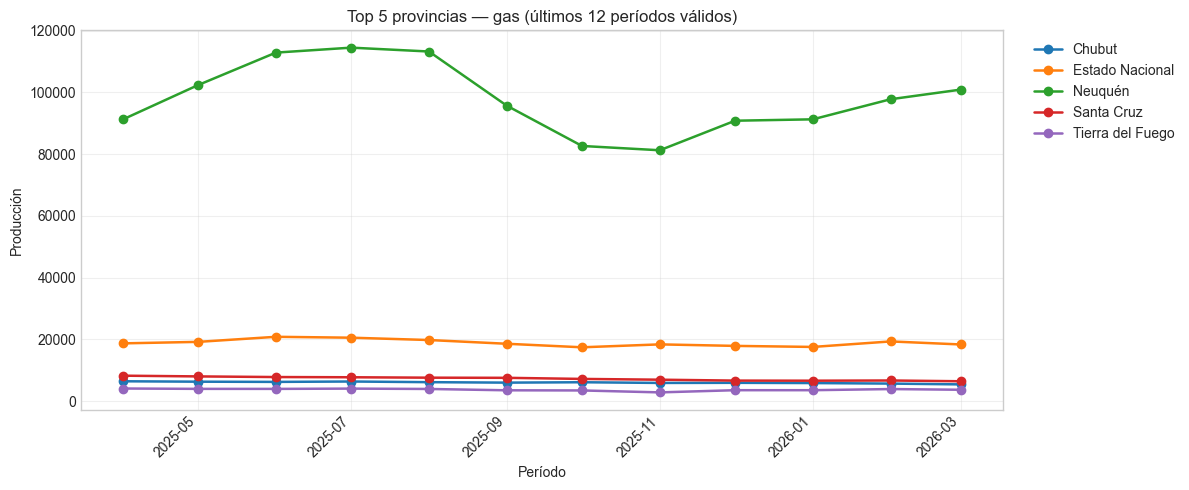

agrupador_nombre,Chubut,Estado Nacional,Neuquén,Santa Cruz,Tierra del Fuego
periodo_str,,,,,
2025-04,6423.16,18705.36,91235.94,8236.78,4080.21
2025-05,6291.90,19186.69,102375.52,7999.74,3964.52
2025-06,6223.49,20829.41,112889.01,7794.46,3957.00
2025-07,6348.98,20540.97,114495.50,7725.18,4048.72
2025-08,6135.82,19787.42,113243.62,7590.02,3933.66
2025-09,5984.11,18576.15,95707.21,7542.42,3502.32
2025-10,6111.64,17430.80,82647.97,7186.38,3453.20
2025-11,5885.55,18376.49,81256.77,6935.64,2825.75
2025-12,5921.74,17886.32,90826.88,6642.00,3534.25


In [58]:
def plot_top5_evolucion(df, producto, agrupador_tipo="provincia", n_periodos=12):
    """Evolución Top 5 usando períodos válidos por producto + agrupador_tipo."""
    sub, info = filter_valid_group(df, producto, agrupador_tipo, threshold=0.5)
    if sub.empty:
        print(f"Sin datos: {producto} / {agrupador_tipo}")
        return

    periodos = (
        sub[["periodo_dt", "periodo_str"]]
        .drop_duplicates()
        .sort_values("periodo_dt")["periodo_str"]
        .tail(n_periodos)
        .tolist()
    )
    ultimo = info["latest_valid_period"]
    top5 = (
        sub[sub["periodo_str"] == ultimo]
        .groupby("agrupador_nombre")["produccion"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
    )
    compare = sub[
        sub["periodo_str"].isin(periodos) & sub["agrupador_nombre"].isin(top5)
    ]
    pivot = (
        compare.pivot_table(
            index="periodo_str",
            columns="agrupador_nombre",
            values="produccion",
            aggfunc="sum",
        )
        .reindex(periodos)
    )
    pivot_dt = pd.to_datetime(pivot.index + "-01")

    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot.columns:
        ax.plot(pivot_dt, pivot[col], marker="o", linewidth=1.8, label=col)
    ax.set_title(
        f"Top 5 {agrupador_tipo}s — {producto} (últimos {len(periodos)} períodos válidos)"
    )
    ax.set_xlabel("Período")
    ax.set_ylabel("Producción")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    display(pivot.round(2))


plot_top5_evolucion(df_sesco_model, "petroleo", "provincia")
plot_top5_evolucion(df_sesco_model, "gas", "provincia")


## 8. Resumen

- Cada recurso exporta `{resource_key}_model_clean.csv` en `data/processed/`.
- El unificado queda en `sesco_produccion_model_clean.csv`.
- Validaciones por recurso en `sesco_validaciones_resumen.csv`.